# Домашнее задание (10 баллов)


(2 балла)
1. закончить реализацию `ClassificationDecisionTree` в decision_tree
    1. реализовать feature_importance_ (для этого метода теста нет, подойдет реализацию любого варианта, базовый способ - рекурсивно суммировать по всем `self.feature_id` `self.q_value_max` и вывести суммы. 
    2. проверить корректность predict 
2. реализовать `BaseSampler`, `ObjectSampler` и `FeatureSampler`. `BaseSampler` - базовый класс, у которого должен быть реализован метода `sample_indices` - вернуть индексы сэмплов. `ObjectSampler` сэплирует объекты, `FeatureSampler` - признаки.
3. реализовать `RandomForestClassifier` в random_forest (predict/predict_proba).

Обратите внимение, что в random_forest в качестве `base_estimator` предполагается использовать `DecisionTreeClassifier` из sklearn, использовать вашу реализацию решающего дерева необязательно. <br> Пример запуска тестов 
- `python -m unittest discover sem_dt_rf/decision_tree/tests`
- `python -m unittest discover sem_dt_rf/random_forest/tests` 

Или через `pytest`
- `python -m pytest sem_dt_rf/decision_tree/tests/test_criterio.py`

In [7]:
!python3 -m unittest discover sem_dt_rf/decision_tree/tests
!python3 -m unittest discover sem_dt_rf/random_forest/tests

/home/b0gcham5/aimasters/ml2/hw1/sem_dt_rf/decision_tree/criterio.py:85: RuntimeWarning: invalid value encountered in divide
  return np.bincount(target, minlength=self.n_classes) / target.shape[0]
..../home/b0gcham5/aimasters/ml2/hw1/sem_dt_rf/decision_tree/criterio.py:71: RuntimeWarning: invalid value encountered in divide
  return np.bincount(target, minlength=self.n_classes) / target.shape[0]
.......
----------------------------------------------------------------------
Ran 11 tests in 0.032s

OK
........
----------------------------------------------------------------------
Ran 8 tests in 0.006s

OK


(1 балл) Для регрессионного дерева необходимо использовать такой критерий:
$$H(R) = \min_c \frac{1}{|R|} \sum_{(x_i, y_i) \in R} (y_i - c)^2$$

Докажите, что минимум H(R) достигается при $c$:

$$ c = \frac{1}{|R|} \sum_{(x_j, y_j) \in R} y_j$$

Proof:
$$c^{*}=\argmin_c \frac{1}{|R|} \sum_{(x_i, y_i) \in R} (y_i - c)^2$$
Using first order optimality condition:
$$H(R)^{'}_c = 0 \to (\frac{1}{|R|} \sum_{(x_i, y_i) \in R} (y_i - c)^2)^{'}_c = \frac{1}{|R|}\sum_{(x_i, y_i) \in R} -2*(y_i - c) = 0$$
$$\frac{1}{|R|}\sum_{(x_i, y_i) \in R}y_i - \frac{1}{|R|}\sum_{(x_i, y_i) \in R} c = \frac{1}{|R|}\sum_{(x_i, y_i) \in R} y_i - c = 0$$
Hence:
$$c^{*} =  \frac{1}{|R|}\sum_{(x_i, y_i) \in R} y_i$$

(3 балла) Реализуйте регрессионное дерево. В качестве критерия необходимо использовать критерий, определённый в пункте 2, в коде есть заглушка `MSECriterion`. В качестве `predict` необходимо использовать среднее значение ответов по всем объектам в листе. В коде нет готовой заглушки, реализуйте по аналогии с `class ClassificationDecisionTree(DecisionTree):`.

Сгенерируйте однопризнаковую выборку для тестирования дерева и покажите работу дерева на этой выборке (пример см. ниже, можно использовать свою версию). Отобразите на одном графике `predict` алгоритма и значение признака. Что меняется при изменении параметра глубины? Сделайте выводы.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# generate example
x_shape = 300
x = np.arange(x_shape) / 100
y = x**3 * np.sin(x**3) + np.random.random(x_shape)

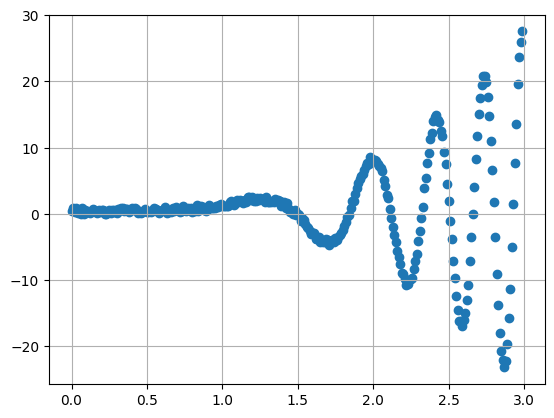

In [3]:
plt.scatter(x, y)
plt.grid()
plt.show()

In [4]:
from sem_dt_rf.decision_tree.decision_tree import RegressionDecisionTree
%load_ext autoreload
%autoreload 2

/home/b0gcham5/.local/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/b0gcham5/.local/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


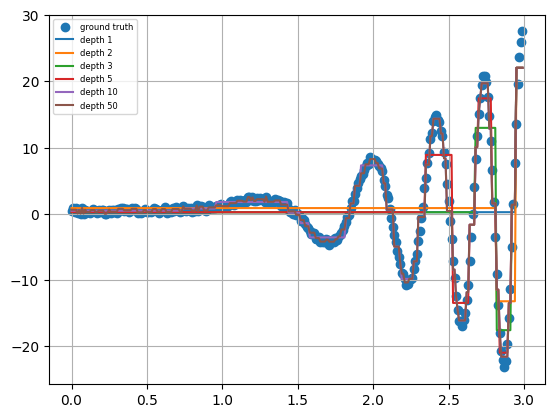

In [5]:
plt.scatter(x, y, label='ground truth')

for depth in [1, 2, 3, 5, 10, 50]:
    tree = RegressionDecisionTree(max_depth=depth)
    tree.fit(x.reshape(-1, 1), y)
    predict = tree.predict(x.reshape(-1, 1))
    plt.plot(x, predict, label=f'depth {depth}')

plt.legend(fontsize=6)
plt.grid()
plt.show()

При увеличении глубины дерева мы видим больше различных "пиков", кривая предсказания становится более ломанной и лучше предсказывает. Но при большой глубине, например в нашем случае 50, происходит переобучение, как видно из предсказаний для точек слева: точки находятся почти на прямой, а предсказания очень зашумлены и скачат вверх и вниз, подстраиваясь под единичные сэмплы.

(4 балла) Протестируйте различные реализации `random_forest` на `fetch_covtype` датасете (можно загрузить с помощью `sklearn.datasets.fetch_covtype`). Возможно, поможет ноутбук с семинара `ensembles_seminar.ipynb`. Для честного сравнения старайтесь использовать похожий набор гиперпараметров.
- ваша реализация (import `RandomForestClassifier as MyRandomForestClassifier` ниже)
- sklearn https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- lightgbm https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMModel.html см. параметр `boosting_type`
- xgboost https://xgboost.readthedocs.io/en/stable/tutorials/rf.html

    Что нужно сделать: 
- Разбейте данные на train и test. 
- Оцените качество алгоритмов по метрике (balanced_accuracy_score)[https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html]
- Оцените время работы `train` и `predict`
- Сделайте выводы

In [6]:
import sys
sys.path.extend(['./']) # change your path

In [7]:
from sem_dt_rf.random_forest.random_forest import RandomForestClassifier as MyRandomForestClassifier

In [9]:
from sklearn.datasets import fetch_covtype
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import xgboost as xgb

In [10]:
cov_type = fetch_covtype()

In [11]:
x_train, x_test, y_train, y_test = train_test_split(cov_type['data'], cov_type['target'], test_size=0.3, random_state=0)
y_train -= 1
y_test -= 1 

In [12]:
clf = MyRandomForestClassifier(n_estimators=100, max_depth=8, random_state=0, max_objects_samples=0.632)

In [13]:
%%time
clf.fit(x_train, y_train)

CPU times: user 1min 56s, sys: 3.35 s, total: 2min
Wall time: 2min


In [14]:
%%time
pred = clf.predict(x_test)

CPU times: user 9.35 s, sys: 4.07 s, total: 13.4 s
Wall time: 13.4 s


In [16]:
my_score = balanced_accuracy_score(y_test, pred)

In [17]:
clf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=0)

In [18]:
%%time
clf.fit(x_train, y_train)

CPU times: user 36.9 s, sys: 39.4 ms, total: 37 s
Wall time: 37 s


RandomForestClassifier(max_depth=8, random_state=0)

In [19]:
%%time
pred = clf.predict(x_test)

CPU times: user 1.02 s, sys: 874 μs, total: 1.02 s
Wall time: 1.02 s


In [20]:
sklearn_score = balanced_accuracy_score(y_test, pred)

In [21]:
params = {
    'num_leaves': 2 ** 8,
    'min_data_in_leaf': 50,
    'objective': 'multiclass',
    'num_classes': len(np.unique(y_train)),
    'max_depth': 8,
    "boosting": "rf",
    "seed": 0,
    "bagging_frequency": 0.65,
    "subsample": .632,
    "subsample_freq": 1,
    "verbose": -1,
}
data = lgb.Dataset(data=x_train, label=y_train)

In [22]:
%%time
clf = lgb.train(params, train_set=data, num_boost_round=100)

CPU times: user 2min 19s, sys: 697 ms, total: 2min 20s
Wall time: 12.2 s


In [23]:
%%time
pred = clf.predict(x_test)

CPU times: user 18.4 s, sys: 66.5 ms, total: 18.5 s
Wall time: 1.69 s


In [24]:
lgb_score = balanced_accuracy_score(y_test, np.argmax(pred, axis=1))

In [25]:
params = {
    "booster": "gbtree",
    "subsample": .632,
    "max_depth": 8,
    "num_parallel_tree": 100,
    "objective": "multi:softmax",
    "num_class": len(np.unique(y_train)),
    "eta":1,
    "random_state": 0,
    "n_jobs": -1,
}
data = xgb.DMatrix(x_train, label=y_train)
test_data = xgb.DMatrix(x_test)

In [26]:
%%time
clf = xgb.train(params, data, num_boost_round=1)

CPU times: user 4min 23s, sys: 474 ms, total: 4min 23s
Wall time: 22.3 s


In [27]:
%%time
pred = clf.predict(test_data)

CPU times: user 4.49 s, sys: 0 ns, total: 4.49 s
Wall time: 384 ms


In [28]:
xgb_score = balanced_accuracy_score(y_test, pred)

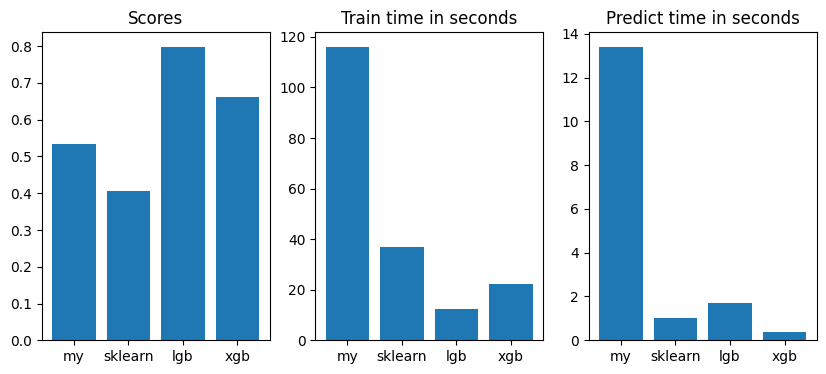

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

axes[0].bar(x=['my', 'sklearn', 'lgb', 'xgb'], height=[my_score, sklearn_score, lgb_score, xgb_score])
axes[0].set_title('Scores')

axes[1].bar(x=['my', 'sklearn', 'lgb', 'xgb'], height=[116, 37, 12.2, 22.3])
axes[1].set_title('Train time in seconds')

axes[2].bar(x=['my', 'sklearn', 'lgb', 'xgb'], height=[13.4, 1.02, 1.69, 0.384])
axes[2].set_title('Predict time in seconds')

plt.show()

Как видно из графиков, самописная реализация случайного леса на питоне оказалась самой долгой по обучению и инференсу, что ожидаемо. Правда скор выше чем у склерна, видимо доп настройки реализации в склерне мешают. В обучении самый быстрый оказался lgm(на то он и light), затем xgb и sklearn rf. Библиотеки бустинга впереди по скорости, особенно lgb. Что касается инференса, то sklearn rf уже обгоняет по скорости lgb, как xgb. Xgb очень хорош при инференсе по скорости, как видим, топ 1 - но на обучении тратит больше времени.

По скору картинка тоже +- ожидаемая(кроме того что самописный rf лучше sklearn). Библиотеки бустингов заметно выше по скору, особенно lgm - отличный кандидат не только по скору, но и по скорости.